In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import numpy as np
from pybaseball import statcast, playerid_reverse_lookup
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

GAME_DATE = '2026-05-18'
OPPONENT = 'NYY'
RESULT = 'TBD'
STARTER_NAME = 'Corbin, Patrick'
HOME_AWAY = 'AWAY'

SEASON_W = 21
SEASON_L = 25
SEASON_RS = 0
SEASON_RA = 0

SPOTLIGHT_PITCHER = 'Rodríguez, Yariel'

PITCH_COLORS = {
    'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
    'CU': '#f39c12', 'SI': '#1abc9c', 'FC': '#95a5a6',
    'ST': '#9b59b6', 'KC': '#e67e22', 'FS': '#34495e',
    'SV': '#8e44ad', 'KN': '#7f8c8d'
}
PITCH_NAMES = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'CU': 'Curveball', 'SI': 'Sinker', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve', 'FS': 'Splitter',
    'SV': 'Slurve', 'KN': 'Knuckle'
}

print("=== Blue Jays Game Report v2.1: " + GAME_DATE + " vs " + OPPONENT + " (" + RESULT + ") ===")
print("Season Record: " + str(SEASON_W) + "-" + str(SEASON_L))
print("Spotlight Pitcher: " + SPOTLIGHT_PITCHER)

=== Blue Jays Game Report v2.1: 2026-05-18 vs NYY (TBD) ===
Season Record: 21-25
Spotlight Pitcher: Rodríguez, Yariel


In [27]:
game_data = statcast(start_dt=GAME_DATE, end_dt=GAME_DATE)

if 'TOR' in game_data['home_team'].values:
    jays_pitching = game_data[game_data['home_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    print("Blue Jays: HOME")
else:
    jays_pitching = game_data[game_data['away_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    print("Blue Jays: AWAY")

print("Total pitches in game: " + str(len(game_data)))
print("Blue Jays pitching data: " + str(len(jays_pitchers)) + " pitches")
print("Blue Jays batting data: " + str(len(jays_batting)) + " pitches")

starter = jays_pitchers[jays_pitchers['player_name'] == STARTER_NAME]
print("\n" + STARTER_NAME + ": " + str(len(starter)) + " pitches")

print("\n=== All Blue Jays pitchers in this game ===")
for name in jays_pitchers['player_name'].unique():
    count = len(jays_pitchers[jays_pitchers['player_name'] == name])
    print("  " + name + ": " + str(count) + " pitches")

This is a large query, it may take a moment to complete


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.41it/s]

Blue Jays: AWAY
Total pitches in game: 4110
Blue Jays pitching data: 158 pitches
Blue Jays batting data: 167 pitches

Corbin, Patrick: 79 pitches

=== All Blue Jays pitchers in this game ===
  Hoffman, Jeff: 17 pitches
  Rodríguez, Yariel: 20 pitches
  Macko, Adam: 15 pitches
  Fisher, Braydon: 27 pitches
  Corbin, Patrick: 79 pitches


In [28]:
print("=" * 60)
print("  " + STARTER_NAME + " — Pitch Arsenal Performance (" + str(len(starter)) + " pitches)")
print("=" * 60)

print("{:<12} {:>4} {:>7} {:>7} {:>8} {:>7} {:>8} {:>6}".format(
    'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%', 'Chase%', 'Grade'))
print("-" * 65)

for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt]
    count = len(pt_data)
    usage = count / len(starter) * 100
    avg_velo = pt_data['release_speed'].mean()

    swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
    swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                           'foul', 'foul_tip', 'hit_into_play',
                                           'hit_into_play_no_out', 'hit_into_play_score']).sum()
    whiff_rate = (swinging / swings * 100) if swings > 0 else 0

    called = (pt_data['description'] == 'called_strike').sum()
    csw = (swinging + called) / count * 100

    outside_zone = pt_data[(pt_data['plate_x'].abs() > 0.83) |
                           (pt_data['plate_z'] < 1.5) |
                           (pt_data['plate_z'] > 3.5)]
    chases = outside_zone['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                'foul', 'foul_tip', 'hit_into_play',
                                                'hit_into_play_no_out', 'hit_into_play_score']).sum()
    chase_rate = (chases / len(outside_zone) * 100) if len(outside_zone) > 0 else 0

    if whiff_rate >= 30: grade = '🟢 A'
    elif whiff_rate >= 20: grade = '🟢 B'
    elif whiff_rate >= 12: grade = '🟡 C'
    else: grade = '🔴 D'

    print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>7.1f}% {:>6.1f}% {:>7.1f}%  {}".format(
        PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, chase_rate, grade))

  Corbin, Patrick — Pitch Arsenal Performance (79 pitches)
Pitch           #   Usage    Velo   Whiff%    CSW%   Chase%  Grade
-----------------------------------------------------------------
Slider         28   35.4%   80.6    33.3%   21.4%    42.9%  🟢 A
Changeup       19   24.1%   77.7    33.3%   15.8%    30.8%  🟢 A
Cutter         14   17.7%   87.0    14.3%   21.4%    55.6%  🟡 C
Sinker         14   17.7%   92.3     0.0%   14.3%    33.3%  🔴 D
Curveball       2    2.5%   73.2     0.0%   50.0%     0.0%  🔴 D
4-Seam          2    2.5%   92.1     0.0%    0.0%     0.0%  🔴 D


In [29]:
print("=== " + STARTER_NAME + " — Pitch Movement (inches) ===")
movement = starter.groupby('pitch_type').agg(
    h_break=('pfx_x', lambda x: x.mean() * 12),
    v_break=('pfx_z', lambda x: x.mean() * 12),
    count=('pitch_type', 'count')
).round(1)
movement = movement[movement['count'] >= 2]
print(movement)

=== Corbin, Patrick — Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
CH             10.6      8.8     19
CU             -2.0     -6.0      2
FC             -1.3      6.4     14
FF              8.2     15.3      2
SI             15.4     11.9     14
SL             -1.7      0.2     28


Chart saved!


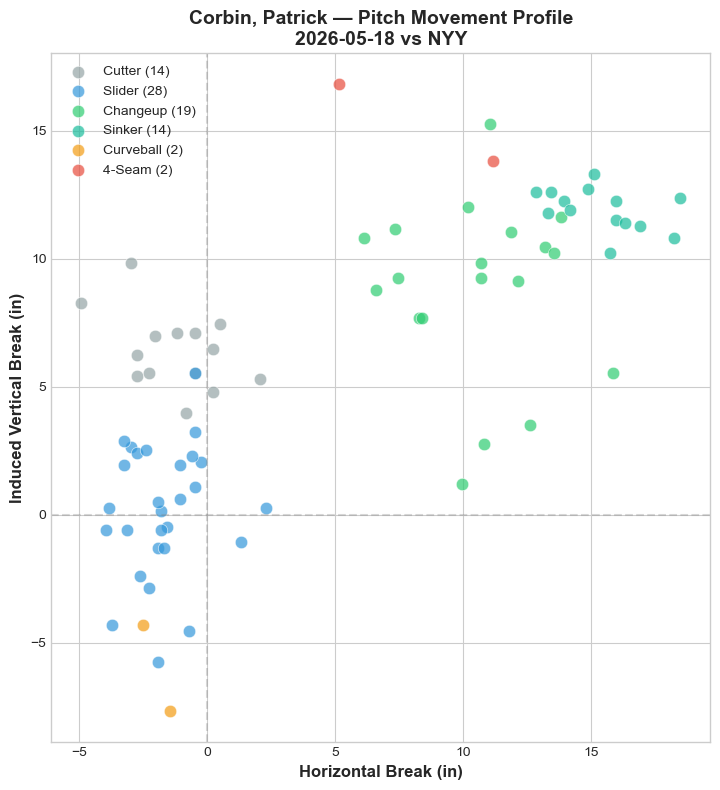

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

for pt in starter['pitch_type'].unique():
    data = starter[starter['pitch_type'] == pt].dropna(subset=['pfx_x', 'pfx_z'])
    if len(data) >= 2:
        ax.scatter(data['pfx_x'] * 12, data['pfx_z'] * 12,
                   c=PITCH_COLORS.get(pt, '#95a5a6'), s=80, alpha=0.7,
                   label=PITCH_NAMES.get(pt, pt) + " (" + str(len(data)) + ")",
                   edgecolors='white', linewidth=0.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Horizontal Break (in)', fontsize=12, fontweight='bold')
ax.set_ylabel('Induced Vertical Break (in)', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Pitch Movement Profile\n' + GAME_DATE + ' vs ' + OPPONENT,
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../visualizations/movement_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [31]:
print("=== " + STARTER_NAME + " vs LHB/RHB ===")
lr_split = starter.groupby('stand').agg(
    pitches=('pitch_type', 'count'),
    avg_velo=('release_speed', 'mean'),
    swinging_strikes=('description', lambda x: (x.isin(['swinging_strike', 'swinging_strike_blocked'])).sum())
).round(1)
lr_split['whiff_per_pitch'] = (lr_split['swinging_strikes'] / lr_split['pitches'] * 100).round(1)
print(lr_split)

=== Corbin, Patrick vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L           36      84.8                 4             11.1
R           43      81.9                 5             11.6


Chart saved!


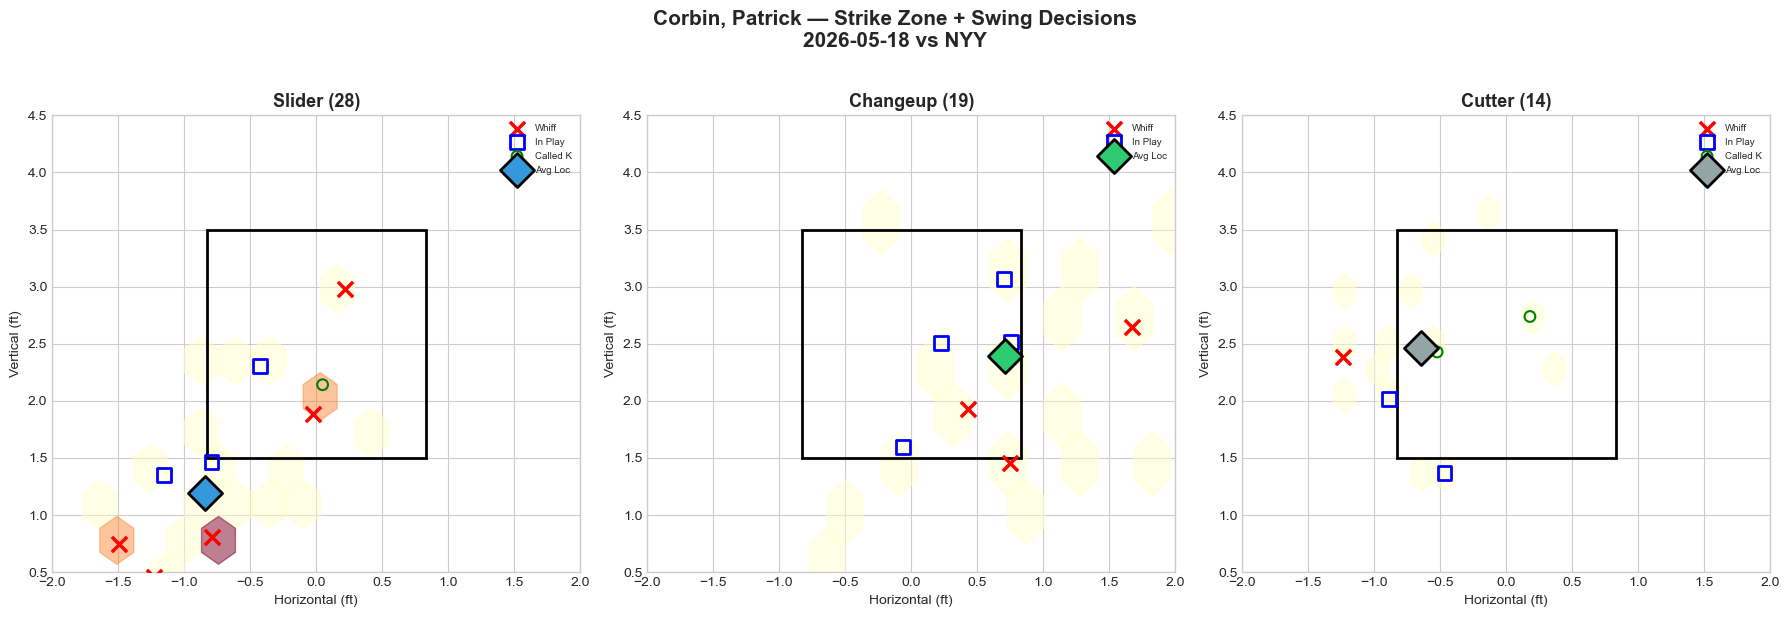

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
main_pitches = starter['pitch_type'].value_counts().head(3).index.tolist()

for idx, pt in enumerate(main_pitches):
    ax = axes[idx]
    data = starter[starter['pitch_type'] == pt].dropna(subset=['plate_x', 'plate_z'])

    if len(data) > 0:
        ax.hexbin(data['plate_x'], data['plate_z'], gridsize=10, cmap='YlOrRd', mincnt=1, alpha=0.5)

        zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor='black', linewidth=2)
        ax.add_patch(zone)

        whiffs = data[data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])]
        if len(whiffs) > 0:
            ax.scatter(whiffs['plate_x'], whiffs['plate_z'],
                      marker='x', s=120, c='red', linewidths=2.5, zorder=5, label='Whiff')

        in_play_data = data[data['description'].isin(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score'])]
        if len(in_play_data) > 0:
            ax.scatter(in_play_data['plate_x'], in_play_data['plate_z'],
                      marker='s', s=100, facecolors='none', edgecolors='blue',
                      linewidths=2, zorder=5, label='In Play')

        called_k = data[data['description'] == 'called_strike']
        if len(called_k) > 0:
            ax.scatter(called_k['plate_x'], called_k['plate_z'],
                      marker='o', s=60, facecolors='none', edgecolors='green',
                      linewidths=1.5, zorder=4, label='Called K')

        avg_x = data['plate_x'].mean()
        avg_z = data['plate_z'].mean()
        ax.scatter(avg_x, avg_z, marker='D', s=300, c=PITCH_COLORS.get(pt, '#95a5a6'),
                  edgecolors='black', linewidths=2, zorder=6, label='Avg Loc')

        ax.set_xlim(-2, 2)
        ax.set_ylim(0.5, 4.5)
        ax.set_title(PITCH_NAMES.get(pt, pt) + ' (' + str(len(data)) + ')', fontsize=13, fontweight='bold')
        ax.set_xlabel('Horizontal (ft)', fontsize=10)
        ax.set_ylabel('Vertical (ft)', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle(STARTER_NAME + ' — Strike Zone + Swing Decisions\n' + GAME_DATE + ' vs ' + OPPONENT,
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/zone_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [33]:
seq_data = starter.dropna(subset=['balls', 'strikes']).copy()
seq_data['count'] = seq_data['balls'].astype(int).astype(str) + '-' + seq_data['strikes'].astype(int).astype(str)

count_groups = {
    'First pitch (0-0)': ['0-0'],
    'Ahead (0-1, 0-2, 1-2)': ['0-1', '0-2', '1-2'],
    'Behind (1-0, 2-0, 3-0, 2-1, 3-1)': ['1-0', '2-0', '3-0', '2-1', '3-1'],
    'Even (1-1, 2-2)': ['1-1', '2-2'],
    'Full count (3-2)': ['3-2']
}

print("=== " + STARTER_NAME + " — Pitch Selection by Count ===\n")

for group_name, counts in count_groups.items():
    group_data = seq_data[seq_data['count'].isin(counts)]
    if len(group_data) > 0:
        mix = group_data['pitch_type'].value_counts(normalize=True).mul(100).round(1)
        print("--- " + group_name + " (" + str(len(group_data)) + " pitches) ---")
        for pt, pct in mix.items():
            print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(pct) + "%")
        print()

strikeouts = starter[starter['events'] == 'strikeout']
if len(strikeouts) > 0:
    print("=== Strikeout Pitch (" + str(len(strikeouts)) + " K's) ===")
    print(strikeouts['pitch_type'].value_counts())

=== Corbin, Patrick — Pitch Selection by Count ===

--- First pitch (0-0) (20 pitches) ---
  Slider: 30.0%
  Cutter: 20.0%
  Changeup: 20.0%
  Sinker: 20.0%
  Curveball: 10.0%

--- Ahead (0-1, 0-2, 1-2) (24 pitches) ---
  Slider: 54.2%
  Changeup: 25.0%
  Cutter: 8.3%
  Sinker: 8.3%
  4-Seam: 4.2%

--- Behind (1-0, 2-0, 3-0, 2-1, 3-1) (16 pitches) ---
  Cutter: 37.5%
  Changeup: 31.2%
  Slider: 25.0%
  Sinker: 6.2%

--- Even (1-1, 2-2) (15 pitches) ---
  Sinker: 46.7%
  Slider: 26.7%
  Changeup: 13.3%
  4-Seam: 6.7%
  Cutter: 6.7%

--- Full count (3-2) (4 pitches) ---
  Changeup: 50.0%
  Cutter: 25.0%
  Slider: 25.0%

=== Strikeout Pitch (3 K's) ===
pitch_type
SL    2
FC    1
Name: count, dtype: int64


In [34]:
batter_ids = starter['batter'].unique()

try:
    batter_names_df = playerid_reverse_lookup(batter_ids, key_type='mlbam')
    batter_name_map = dict(zip(
        batter_names_df['key_mlbam'],
        batter_names_df['name_last'] + ', ' + batter_names_df['name_first']
    ))
except:
    batter_name_map = {}

starter_with_names = starter.copy()
starter_with_names['batter_name'] = starter_with_names['batter'].map(batter_name_map)

batter_summary = starter_with_names.groupby('batter_name').agg(
    pitches=('pitch_type', 'count'),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: (x == 'walk').sum()),
    avg_exit_velo=('launch_speed', lambda x: x.dropna().mean() if len(x.dropna()) > 0 else 0)
).sort_values('pitches', ascending=False)

print("=== Top Opposing Batters vs " + STARTER_NAME + " ===\n")
print(batter_summary.head(5).round(1))

print("\n=== Detailed Pitch Breakdown ===\n")
for batter_name in batter_summary.head(3).index:
    batter_data = starter_with_names[starter_with_names['batter_name'] == batter_name]
    print("--- " + str(batter_name) + " (" + str(len(batter_data)) + " pitches) ---")
    print("  Pitches faced: " + str(batter_data['pitch_type'].value_counts().to_dict()))

    results = batter_data['description'].value_counts()
    whiffs = results.get('swinging_strike', 0) + results.get('swinging_strike_blocked', 0)
    fouls = results.get('foul', 0) + results.get('foul_tip', 0)
    called = results.get('called_strike', 0)
    balls = results.get('ball', 0) + results.get('blocked_ball', 0)
    in_play = results.get('hit_into_play', 0) + results.get('hit_into_play_no_out', 0) + results.get('hit_into_play_score', 0)

    print("  Results: " + str(whiffs) + " whiffs, " + str(fouls) + " fouls, " + str(called) + " called strikes, " + str(balls) + " balls, " + str(in_play) + " in play")

    events = batter_data['events'].dropna()
    if len(events) > 0:
        print("  Outcomes: " + str(events.tolist()))
    print()

=== Top Opposing Batters vs Corbin, Patrick ===

                   pitches  hits  strikeouts  walks  avg_exit_velo
batter_name                                                       
rice, ben               12     1           0      0           74.3
chisholm, jazz          11     0           1      0           80.7
rosario, amed           11     0           1      0           58.6
goldschmidt, paul       10     2           0      1           91.9
schuemann, max          10     0           0      2           50.3

=== Detailed Pitch Breakdown ===

--- rice, ben (12 pitches) ---
  Pitches faced: {'SL': 9, 'FC': 1, 'SI': 1, 'FF': 1}
  Results: 3 whiffs, 2 fouls, 0 called strikes, 4 balls, 3 in play
  Outcomes: ['field_out', 'field_out', 'double']

--- chisholm, jazz (11 pitches) ---
  Pitches faced: {'SI': 6, 'SL': 3, 'FC': 2}
  Results: 0 whiffs, 3 fouls, 3 called strikes, 4 balls, 1 in play
  Outcomes: ['strikeout', 'field_out']

--- rosario, amed (11 pitches) ---
  Pitches faced: {'CH'

Chart saved!


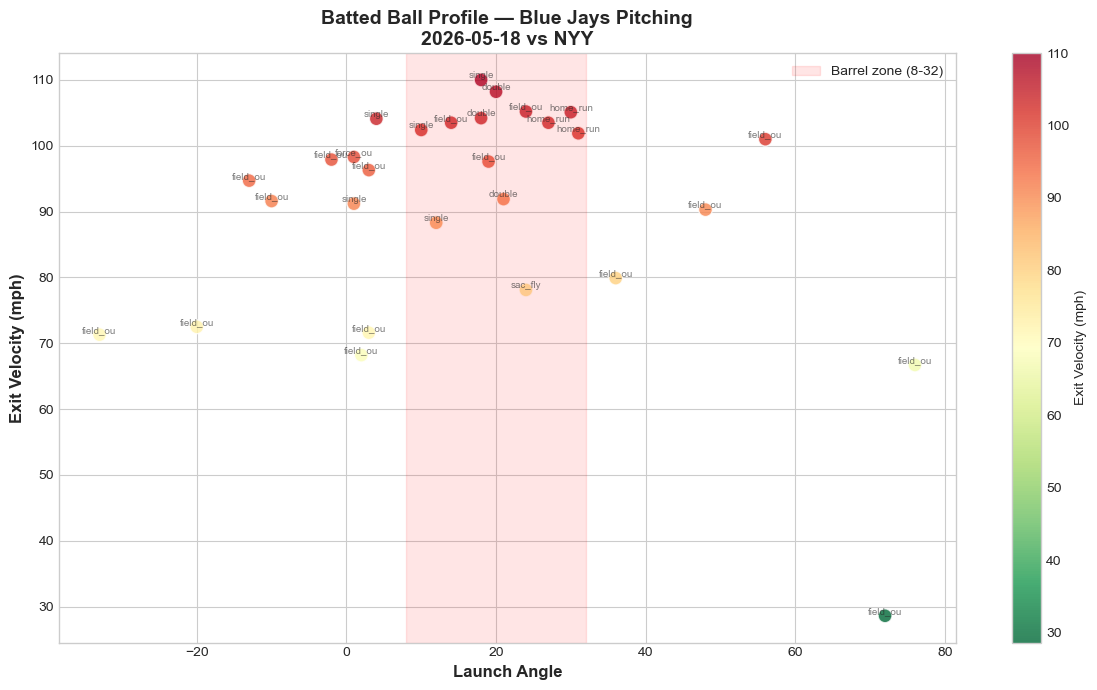


=== Batted Ball Summary ===
Total balls in play: 29
Avg exit velocity: 90.5 mph
Avg launch angle: 17.0
Hard hit (95+ mph): 15/29 (52%)


In [35]:
in_play = jays_pitchers[jays_pitchers['description'].isin(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score'])].dropna(subset=['launch_angle', 'launch_speed'])

if len(in_play) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    scatter = ax.scatter(in_play['launch_angle'], in_play['launch_speed'],
                         c=in_play['launch_speed'], cmap='RdYlGn_r',
                         s=100, edgecolors='white', linewidth=1, alpha=0.8)

    for _, row in in_play.iterrows():
        result = row.get('events', '')
        if pd.notna(result) and result != '':
            ax.annotate(str(result)[:8], xy=(row['launch_angle'], row['launch_speed']),
                        fontsize=7, alpha=0.6, ha='center', va='bottom')

    ax.axvspan(8, 32, alpha=0.1, color='red', label='Barrel zone (8-32)')
    ax.set_xlabel('Launch Angle', fontsize=12, fontweight='bold')
    ax.set_ylabel('Exit Velocity (mph)', fontsize=12, fontweight='bold')
    ax.set_title('Batted Ball Profile — Blue Jays Pitching\n' + GAME_DATE + ' vs ' + OPPONENT,
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(scatter, label='Exit Velocity (mph)')
    plt.tight_layout()
    plt.savefig('../visualizations/batted_balls_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

print("\n=== Batted Ball Summary ===")
print("Total balls in play: " + str(len(in_play)))
print("Avg exit velocity: " + str(round(in_play['launch_speed'].mean(), 1)) + " mph")
print("Avg launch angle: " + str(round(in_play['launch_angle'].mean(), 1)))
hard_hit = (in_play['launch_speed'] >= 95).sum()
hard_pct = round((in_play['launch_speed'] >= 95).mean() * 100)
print("Hard hit (95+ mph): " + str(hard_hit) + "/" + str(len(in_play)) + " (" + str(hard_pct) + "%)")

Chart saved!


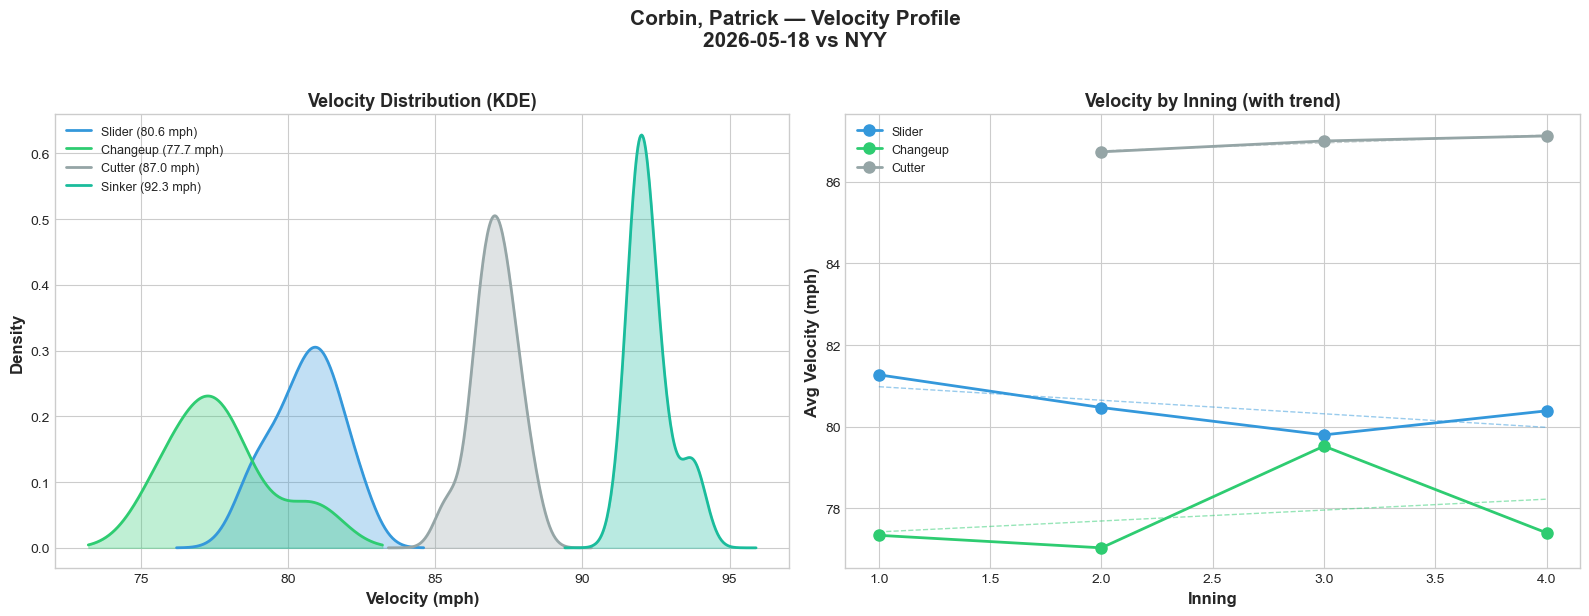

Slider: 81.3 -> 80.4 mph (-0.9 mph)
Changeup: 77.3 -> 77.4 mph (+0.1 mph)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt]['release_speed'].dropna()
    if len(pt_data) >= 3:
        kde = gaussian_kde(pt_data)
        x_range = np.linspace(pt_data.min() - 2, pt_data.max() + 2, 200)
        ax1.fill_between(x_range, kde(x_range), alpha=0.3,
                        color=PITCH_COLORS.get(pt, '#95a5a6'))
        ax1.plot(x_range, kde(x_range),
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2,
                label=PITCH_NAMES.get(pt, pt) + " (" + str(round(pt_data.mean(), 1)) + " mph)")

ax1.set_xlabel('Velocity (mph)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Velocity Distribution (KDE)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2 = axes[1]
pitcher_inning = starter.dropna(subset=['release_speed']).copy()

for pt in starter['pitch_type'].value_counts().head(3).index:
    pt_data = pitcher_inning[pitcher_inning['pitch_type'] == pt]
    inning_velo = pt_data.groupby('inning')['release_speed'].mean()
    if len(inning_velo) >= 2:
        ax2.plot(inning_velo.index, inning_velo.values, '-o',
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2, markersize=8,
                label=PITCH_NAMES.get(pt, pt))
        z = np.polyfit(inning_velo.index, inning_velo.values, 1)
        trend = np.poly1d(z)
        ax2.plot(inning_velo.index, trend(inning_velo.index), '--',
                color=PITCH_COLORS.get(pt, '#95a5a6'), alpha=0.5, linewidth=1)

ax2.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Velocity (mph)', fontsize=12, fontweight='bold')
ax2.set_title('Velocity by Inning (with trend)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle(STARTER_NAME + ' — Velocity Profile\n' + GAME_DATE + ' vs ' + OPPONENT,
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/velocity_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

for pt in starter['pitch_type'].value_counts().head(2).index:
    pt_data = pitcher_inning[pitcher_inning['pitch_type'] == pt]
    first_inn = pt_data[pt_data['inning'] == pt_data['inning'].min()]['release_speed'].mean()
    last_inn = pt_data[pt_data['inning'] == pt_data['inning'].max()]['release_speed'].mean()
    drop = last_inn - first_inn
    print(PITCH_NAMES.get(pt, pt) + ": " + str(round(first_inn, 1)) + " -> " + str(round(last_inn, 1)) + " mph (" + ('+' if drop >= 0 else '') + str(round(drop, 1)) + " mph)")

Chart saved!


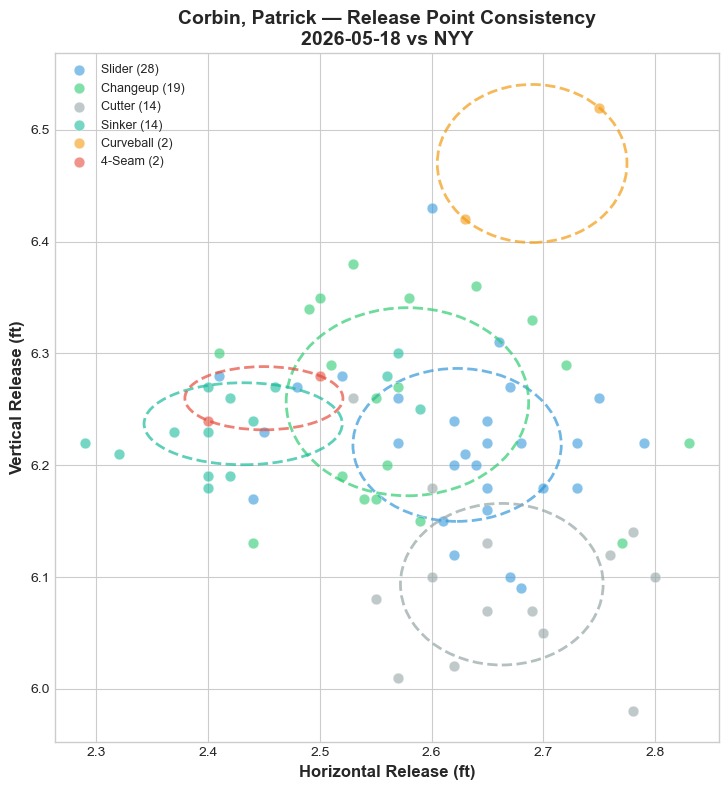


=== Release Point Spread (std dev in inches) ===
  Slider: H=1.1in, V=0.8in, Total=1.4in 🟢 Tight
  Changeup: H=1.3in, V=1.0in, Total=1.6in 🟢 Tight
  Cutter: H=1.1in, V=0.9in, Total=1.4in 🟢 Tight
  Sinker: H=1.1in, V=0.4in, Total=1.2in 🟢 Tight
  Curveball: H=1.0in, V=0.8in, Total=1.3in 🟢 Tight
  4-Seam: H=0.8in, V=0.3in, Total=0.9in 🟢 Tight


In [37]:
fig, ax = plt.subplots(figsize=(8, 8))

for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt].dropna(subset=['release_pos_x', 'release_pos_z'])
    if len(pt_data) >= 2:
        ax.scatter(pt_data['release_pos_x'], pt_data['release_pos_z'],
                  c=PITCH_COLORS.get(pt, '#95a5a6'), s=60, alpha=0.6,
                  label=PITCH_NAMES.get(pt, pt) + " (" + str(len(pt_data)) + ")",
                  edgecolors='white', linewidth=0.5)

        mean_x = pt_data['release_pos_x'].mean()
        mean_z = pt_data['release_pos_z'].mean()
        std_x = pt_data['release_pos_x'].std()
        std_z = pt_data['release_pos_z'].std()
        if std_x > 0 and std_z > 0:
            ellipse = Ellipse((mean_x, mean_z), std_x*2, std_z*2,
                            fill=False, edgecolor=PITCH_COLORS.get(pt, '#95a5a6'),
                            linewidth=2, linestyle='--', alpha=0.7)
            ax.add_patch(ellipse)

ax.set_xlabel('Horizontal Release (ft)', fontsize=12, fontweight='bold')
ax.set_ylabel('Vertical Release (ft)', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Release Point Consistency\n' + GAME_DATE + ' vs ' + OPPONENT,
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../visualizations/release_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

print("\n=== Release Point Spread (std dev in inches) ===")
for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt].dropna(subset=['release_pos_x', 'release_pos_z'])
    if len(pt_data) >= 2:
        h_spread = pt_data['release_pos_x'].std() * 12
        v_spread = pt_data['release_pos_z'].std() * 12
        total = np.sqrt(h_spread**2 + v_spread**2)
        if total < 3: consistency = '🟢 Tight'
        elif total < 5: consistency = '🟡 Moderate'
        else: consistency = '🔴 Inconsistent'
        print("  " + PITCH_NAMES.get(pt, pt) + ": H=" + str(round(h_spread, 1)) + "in, V=" + str(round(v_spread, 1)) + "in, Total=" + str(round(total, 1)) + "in " + consistency)

In [38]:
print("=== " + STARTER_NAME + " — Pitch Tunneling Analysis ===\n")

pitch_types = starter['pitch_type'].value_counts().index.tolist()
tunnel_results = []

for i in range(len(pitch_types)):
    for j in range(i+1, len(pitch_types)):
        pt1, pt2 = pitch_types[i], pitch_types[j]
        d1 = starter[starter['pitch_type'] == pt1].dropna(subset=['release_pos_x', 'release_pos_z', 'plate_x', 'plate_z'])
        d2 = starter[starter['pitch_type'] == pt2].dropna(subset=['release_pos_x', 'release_pos_z', 'plate_x', 'plate_z'])

        if len(d1) >= 3 and len(d2) >= 3:
            rel_diff = np.sqrt(
                (d1['release_pos_x'].mean() - d2['release_pos_x'].mean())**2 +
                (d1['release_pos_z'].mean() - d2['release_pos_z'].mean())**2
            ) * 12

            plate_diff = np.sqrt(
                (d1['plate_x'].mean() - d2['plate_x'].mean())**2 +
                (d1['plate_z'].mean() - d2['plate_z'].mean())**2
            ) * 12

            tunnel_score = plate_diff / rel_diff if rel_diff > 0 else 0
            velo_gap = abs(d1['release_speed'].mean() - d2['release_speed'].mean())

            tunnel_results.append({
                'pair': PITCH_NAMES.get(pt1, pt1) + "/" + PITCH_NAMES.get(pt2, pt2),
                'release_sim': rel_diff,
                'plate_sep': plate_diff,
                'tunnel_score': tunnel_score,
                'velo_gap': velo_gap
            })

if tunnel_results:
    tunnel_df = pd.DataFrame(tunnel_results).sort_values('tunnel_score', ascending=False)
    print("{:<25} {:>12} {:>11} {:>8} {:>9}".format('Pair', 'Release Sim', 'Plate Sep', 'Tunnel', 'Velo Gap'))
    print("-" * 70)
    for _, row in tunnel_df.iterrows():
        if row['tunnel_score'] >= 3: grade = '🟢'
        elif row['tunnel_score'] >= 1.5: grade = '🟡'
        else: grade = '🔴'
        print("{:<25} {:>10.1f}in {:>9.1f}in {}{:>5.1f} {:>7.1f}mph".format(
            row['pair'], row['release_sim'], row['plate_sep'], grade, row['tunnel_score'], row['velo_gap']))

    best = tunnel_df.iloc[0]
    print("\n🏆 Best Tunnel: " + best['pair'] + " (score: " + str(round(best['tunnel_score'], 1)) + ")")

=== Corbin, Patrick — Pitch Tunneling Analysis ===

Pair                       Release Sim   Plate Sep   Tunnel  Velo Gap
----------------------------------------------------------------------
Slider/Changeup                  0.7in      23.6in 🟢 33.4     2.9mph
Slider/Cutter                    1.6in      15.4in 🟢  9.8     6.4mph
Changeup/Cutter                  2.2in      16.3in 🟢  7.4     9.3mph
Slider/Sinker                    2.3in      14.8in 🟢  6.4    11.7mph
Changeup/Sinker                  1.8in       8.9in 🟢  5.0    14.6mph
Cutter/Sinker                    3.3in      10.1in 🟢  3.1     5.3mph

🏆 Best Tunnel: Slider/Changeup (score: 33.4)


=== Corbin, Patrick — Game Score Analysis ===
Game Score: 42
  Base: 50
  + Outs recorded: +11
  + Bonus K's (after 4th): +0
  - Hits: -12
  - Home runs: -4
  - Walks/HBP: -3
  Rating: 🟡 AVERAGE
Chart saved!


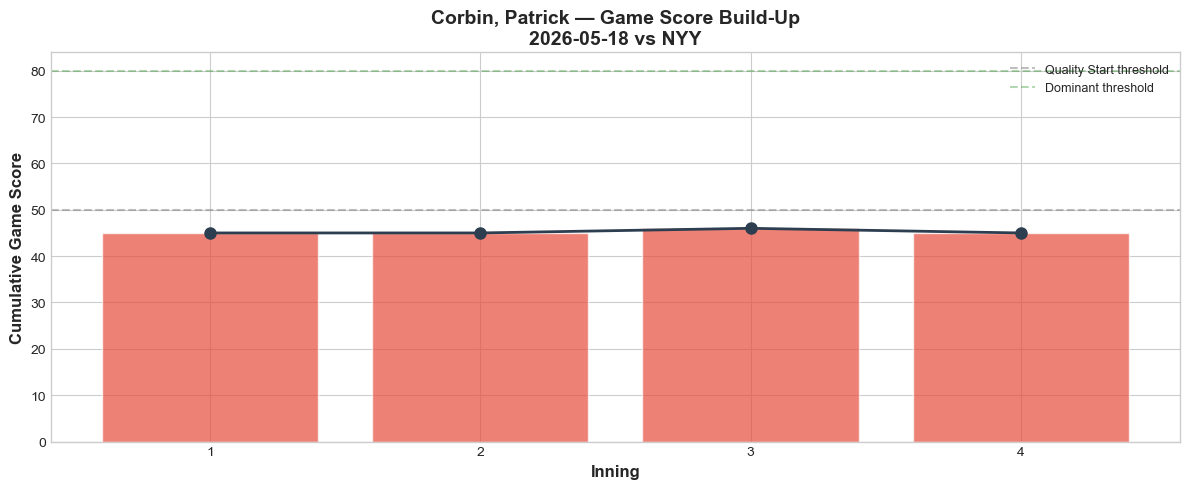

In [39]:
total_outs = len(starter[starter['events'].isin(['strikeout', 'field_out', 'grounded_into_double_play',
                                                   'force_out', 'fielders_choice', 'sac_fly',
                                                   'sac_bunt', 'double_play', 'fielders_choice_out'])])
k_count = len(starter[starter['events'] == 'strikeout'])
hits = len(starter[starter['events'].isin(['single', 'double', 'triple', 'home_run'])])
walks = len(starter[starter['events'].isin(['walk', 'hit_by_pitch'])])
hr = len(starter[starter['events'] == 'home_run'])

game_score = 50 + total_outs - (2 * hits) - (4 * hr) - walks + (2 * max(0, k_count - 4))

print("=== " + STARTER_NAME + " — Game Score Analysis ===")
print("Game Score: " + str(game_score))
print("  Base: 50")
print("  + Outs recorded: +" + str(total_outs))
print("  + Bonus K's (after 4th): +" + str(2 * max(0, k_count - 4)))
print("  - Hits: -" + str(2 * hits))
print("  - Home runs: -" + str(4 * hr))
print("  - Walks/HBP: -" + str(walks))

if game_score >= 80: rating = "🟢 DOMINANT"
elif game_score >= 65: rating = "🟢 EXCELLENT"
elif game_score >= 50: rating = "🟡 QUALITY"
elif game_score >= 40: rating = "🟡 AVERAGE"
else: rating = "🔴 POOR"
print("  Rating: " + rating)

fig, ax = plt.subplots(figsize=(12, 5))
innings = sorted(starter['inning'].unique())
cumulative_score = []
running = 50

for inn in innings:
    inn_data = starter[starter['inning'] == inn]
    inn_outs = len(inn_data[inn_data['events'].isin(['strikeout', 'field_out', 'grounded_into_double_play',
                                                      'force_out', 'fielders_choice', 'sac_fly', 'fielders_choice_out'])])
    inn_k = len(inn_data[inn_data['events'] == 'strikeout'])
    inn_hits = len(inn_data[inn_data['events'].isin(['single', 'double', 'triple', 'home_run'])])
    inn_bb = len(inn_data[inn_data['events'].isin(['walk', 'hit_by_pitch'])])
    inn_hr = len(inn_data[inn_data['events'] == 'home_run'])
    running += inn_outs + inn_k - (2 * inn_hits) - (4 * inn_hr) - inn_bb
    cumulative_score.append(running)

colors = ['#2ecc71' if s >= 50 else '#e74c3c' for s in cumulative_score]
ax.bar(innings, cumulative_score, color=colors, alpha=0.7, edgecolor='white')
ax.plot(innings, cumulative_score, '-o', color='#2c3e50', linewidth=2, markersize=8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Quality Start threshold')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.3, label='Dominant threshold')
ax.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Game Score', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Game Score Build-Up\n' + GAME_DATE + ' vs ' + OPPONENT,
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(innings)
plt.tight_layout()
plt.savefig('../visualizations/gamescore_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


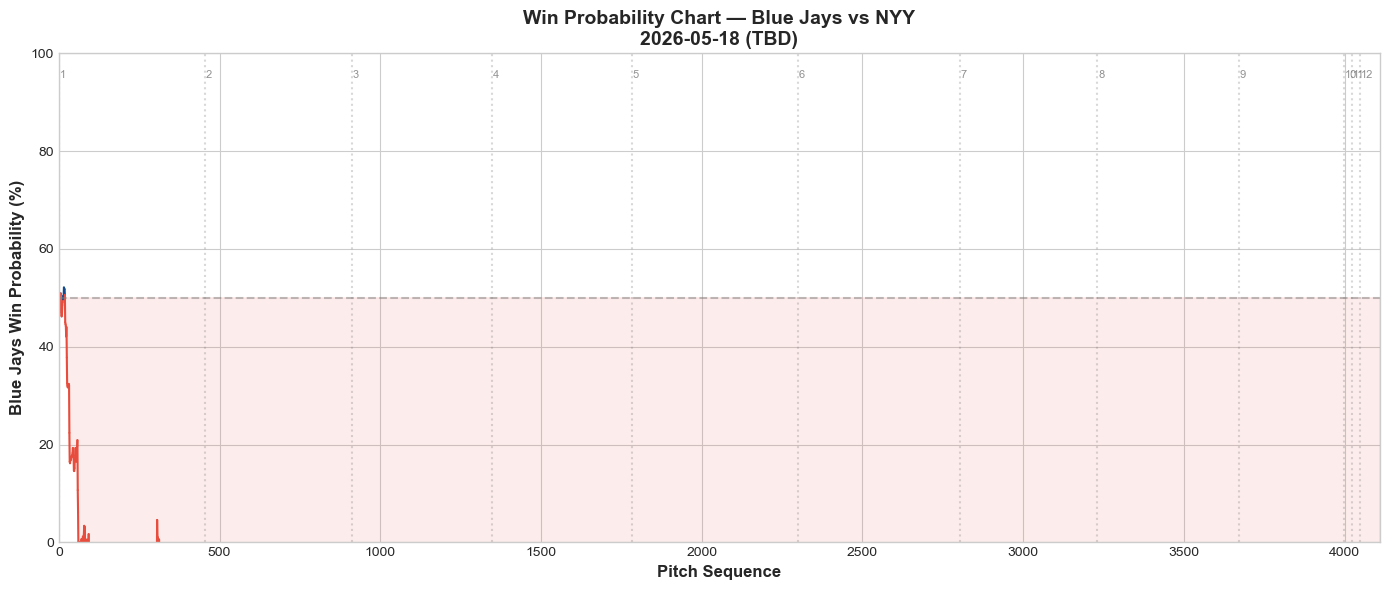


=== Key WPA Moments ===
  📉 Inning 4: Weathers, Ryan — home_run (WP 34.6%)
  📉 Inning 6: Lugo, Seth — home_run (WP 25.4%)
  📈 Inning 7: Rodríguez, Yariel — home_run (WP 34.7%)
  📈 Inning 8: Ashcraft, Graham — home_run (WP 62.0%)
  📈 Inning 9: Ginn, J.T. — home_run (WP 60.8%)
  📉 Inning 9: Zeferjahn, Ryan — single (WP 28.8%)


In [40]:
wpa_data = game_data.dropna(subset=['delta_home_win_exp']).copy()
wpa_data = wpa_data.sort_values(['inning', 'inning_topbot', 'at_bat_number', 'pitch_number'])

if len(wpa_data) > 0:
    wpa_data['cum_home_wp'] = 0.5 + wpa_data['delta_home_win_exp'].cumsum()
    wpa_data['pitch_seq'] = range(len(wpa_data))

    if HOME_AWAY == 'HOME':
        wpa_data['tor_wp'] = wpa_data['cum_home_wp']
    else:
        wpa_data['tor_wp'] = 1 - wpa_data['cum_home_wp']

    fig, ax = plt.subplots(figsize=(14, 6))

    for i in range(1, len(wpa_data)):
        color = '#134A8E' if wpa_data.iloc[i]['tor_wp'] >= 0.5 else '#e74c3c'
        ax.plot([wpa_data.iloc[i-1]['pitch_seq'], wpa_data.iloc[i]['pitch_seq']],
               [wpa_data.iloc[i-1]['tor_wp'] * 100, wpa_data.iloc[i]['tor_wp'] * 100],
               color=color, linewidth=1.5)

    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(wpa_data['pitch_seq'], wpa_data['tor_wp'] * 100, 50,
                   where=wpa_data['tor_wp'] >= 0.5, alpha=0.1, color='#134A8E')
    ax.fill_between(wpa_data['pitch_seq'], wpa_data['tor_wp'] * 100, 50,
                   where=wpa_data['tor_wp'] < 0.5, alpha=0.1, color='#e74c3c')

    for inn in wpa_data['inning'].unique():
        inn_start = wpa_data[wpa_data['inning'] == inn]['pitch_seq'].min()
        ax.axvline(x=inn_start, color='gray', linestyle=':', alpha=0.3)
        ax.text(inn_start + 2, 95, str(int(inn)), fontsize=8, alpha=0.5)

    ax.set_xlabel('Pitch Sequence', fontsize=12, fontweight='bold')
    ax.set_ylabel('Blue Jays Win Probability (%)', fontsize=12, fontweight='bold')
    ax.set_title('Win Probability Chart — Blue Jays vs ' + OPPONENT + '\n' + GAME_DATE + ' (' + RESULT + ')',
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_xlim(0, len(wpa_data))
    plt.tight_layout()
    plt.savefig('../visualizations/wpa_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    print("\n=== Key WPA Moments ===")
    top_moments = wpa_data.nlargest(3, 'delta_home_win_exp')
    bot_moments = wpa_data.nsmallest(3, 'delta_home_win_exp')
    key = pd.concat([top_moments, bot_moments]).sort_values('pitch_seq')
    for _, row in key.iterrows():
        direction = "📈" if row['delta_home_win_exp'] > 0 else "📉"
        wp_change = abs(row['delta_home_win_exp'] * 100)
        player = row.get('player_name', 'Unknown')
        event = row.get('events', row.get('description', ''))
        inning = int(row['inning'])
        print("  " + direction + " Inning " + str(inning) + ": " + str(player) + " — " + str(event) + " (WP " + str(round(wp_change, 1)) + "%)")
else:
    print("WPA data not available for this game.")

Chart saved!


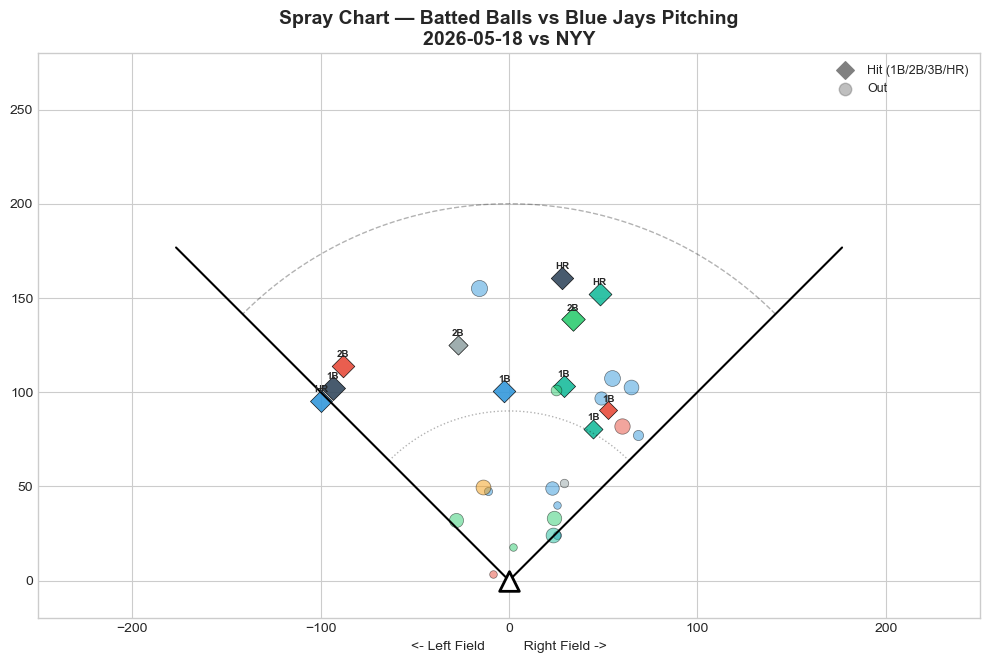


=== Spray Summary ===
Total batted balls tracked: 29
Hits: 11 (38%)
Pull: 9 (31%) | Center: 17 (59%) | Oppo: 3 (10%)


In [41]:
spray_data = jays_pitchers.dropna(subset=['hc_x', 'hc_y']).copy()

if len(spray_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))

    spray_data['spray_x'] = spray_data['hc_x'] - 125.42
    spray_data['spray_y'] = 199.58 - spray_data['hc_y']

    theta1 = np.radians(45)
    theta2 = np.radians(135)
    r = 250
    ax.plot([0, r * np.cos(theta1)], [0, r * np.sin(theta1)], 'k-', linewidth=1.5)
    ax.plot([0, r * np.cos(theta2)], [0, r * np.sin(theta2)], 'k-', linewidth=1.5)

    arc_angles = np.linspace(theta1, theta2, 100)
    ax.plot(200 * np.cos(arc_angles), 200 * np.sin(arc_angles), 'k--', alpha=0.3, linewidth=1)
    ax.plot(90 * np.cos(arc_angles), 90 * np.sin(arc_angles), 'k:', alpha=0.3, linewidth=1)

    for _, row in spray_data.iterrows():
        event = row.get('events', '')
        pt = row.get('pitch_type', '')
        ev = row.get('launch_speed', 0)

        color = PITCH_COLORS.get(pt, '#95a5a6')
        if pd.notna(ev):
            size = max(30, min(200, (ev - 60) * 3))
        else:
            size = 50

        if event in ['single', 'double', 'triple', 'home_run']:
            marker = 'D'
            alpha = 0.9
        else:
            marker = 'o'
            alpha = 0.5

        ax.scatter(row['spray_x'], row['spray_y'], c=color, s=size,
                  marker=marker, alpha=alpha, edgecolors='black', linewidth=0.5)

        if event in ['single', 'double', 'triple', 'home_run']:
            label_map = {'single': '1B', 'double': '2B', 'triple': '3B', 'home_run': 'HR'}
            ax.annotate(label_map.get(event, ''),
                       xy=(row['spray_x'], row['spray_y']),
                       fontsize=7, fontweight='bold', ha='center', va='bottom',
                       xytext=(0, 5), textcoords='offset points')

    ax.scatter(0, 0, marker='^', s=200, c='white', edgecolors='black', linewidth=2, zorder=10)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-20, 280)
    ax.set_aspect('equal')
    ax.set_title('Spray Chart — Batted Balls vs Blue Jays Pitching\n' + GAME_DATE + ' vs ' + OPPONENT,
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('<- Left Field          Right Field ->', fontsize=10)
    ax.scatter([], [], marker='D', c='gray', s=80, label='Hit (1B/2B/3B/HR)')
    ax.scatter([], [], marker='o', c='gray', s=80, alpha=0.5, label='Out')
    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.savefig('../visualizations/spray_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    total_bip = len(spray_data)
    hits_list = ['single', 'double', 'triple', 'home_run']
    hits_count = len(spray_data[spray_data['events'].isin(hits_list)])
    hit_pct = round(hits_count / total_bip * 100)
    print("\n=== Spray Summary ===")
    print("Total batted balls tracked: " + str(total_bip))
    print("Hits: " + str(hits_count) + " (" + str(hit_pct) + "%)")

    pull = spray_data[spray_data['spray_x'] > 30]
    center = spray_data[(spray_data['spray_x'] >= -30) & (spray_data['spray_x'] <= 30)]
    oppo = spray_data[spray_data['spray_x'] < -30]
    print("Pull: " + str(len(pull)) + " (" + str(round(len(pull)/total_bip*100)) + "%)"
          + " | Center: " + str(len(center)) + " (" + str(round(len(center)/total_bip*100)) + "%)"
          + " | Oppo: " + str(len(oppo)) + " (" + str(round(len(oppo)/total_bip*100)) + "%)")
else:
    print("No spray chart data available.")

In [42]:
if SEASON_RS > 0 and SEASON_RA > 0:
    game_rs = int(RESULT.split()[1].split('-')[0]) if 'W' in RESULT else int(RESULT.split()[1].split('-')[1])
    game_ra = int(RESULT.split()[1].split('-')[1]) if 'W' in RESULT else int(RESULT.split()[1].split('-')[0])
    new_rs = SEASON_RS + game_rs
    new_ra = SEASON_RA + game_ra
    new_w = SEASON_W + (1 if 'W' in RESULT else 0)
    new_l = SEASON_L + (1 if 'L' in RESULT else 0)
    total_games = new_w + new_l
    pyth = new_rs**1.83 / (new_rs**1.83 + new_ra**1.83)
    pyth_w = round(pyth * total_games)
    luck = new_w - pyth_w
    print("Actual: " + str(new_w) + "-" + str(new_l) + " | Pythagorean: " + str(pyth_w) + "-" + str(total_games - pyth_w))
    if luck > 0: print("🍀 OVERPERFORMING by " + str(luck) + " wins")
    elif luck < 0: print("😤 UNDERPERFORMING by " + str(abs(luck)) + " wins")
    else: print("📊 Record matches run differential perfectly")
else:
    print("⚠️ Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker")

⚠️ Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker


=== Corbin, Patrick — Pitch Run Value by Inning ===

Chart saved!


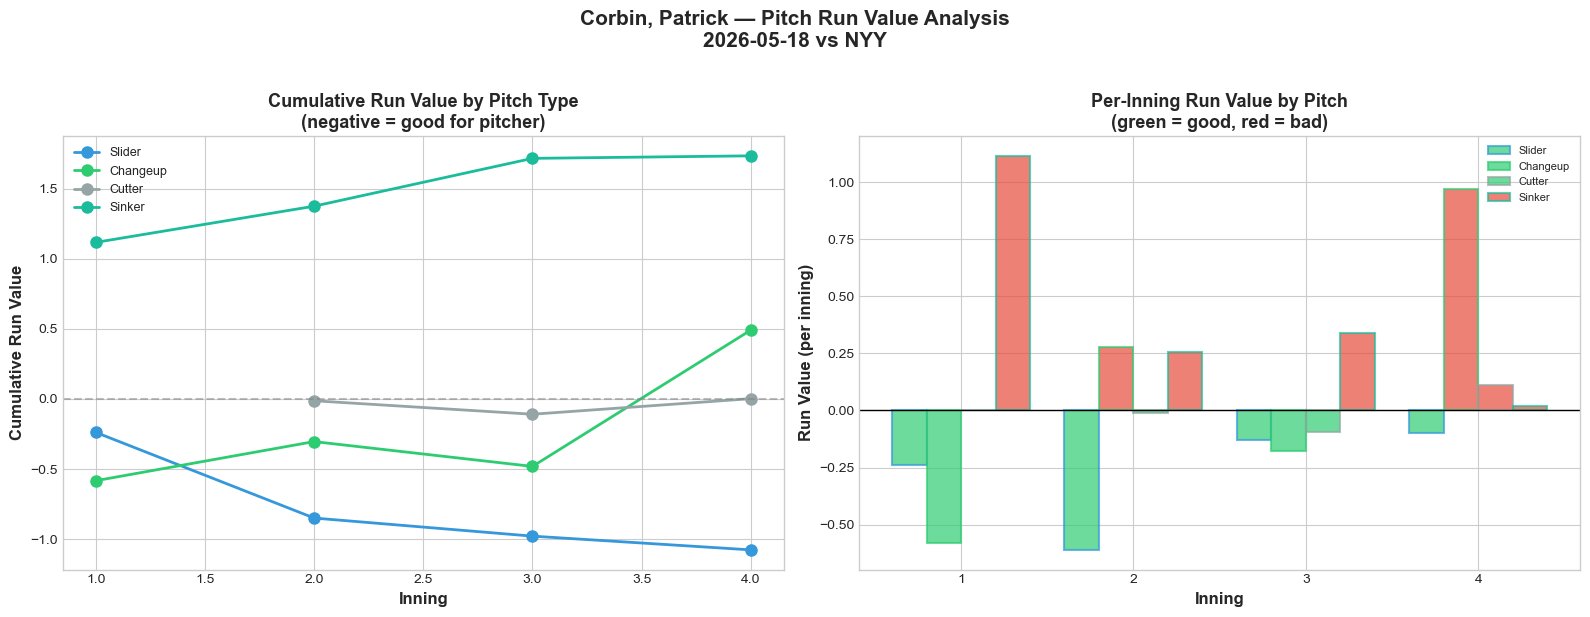


=== Total Run Value by Pitch Type ===
  🟢 Slider: -1.076 total RV (-0.0384 per pitch, 28 pitches)
  🔴 Changeup: 0.491 total RV (0.0258 per pitch, 19 pitches)
  🟡 Cutter: 0.002 total RV (0.0001 per pitch, 14 pitches)
  🔴 Sinker: 1.733 total RV (0.1238 per pitch, 14 pitches)
  🟡 Curveball: -0.086 total RV (-0.043 per pitch, 2 pitches)
  🔴 4-Seam: 0.786 total RV (0.393 per pitch, 2 pitches)

🏆 Most Effective: Slider
⚠️ Least Effective: Sinker


In [43]:
print("=== " + STARTER_NAME + " — Pitch Run Value by Inning ===\n")

rv_data = starter.dropna(subset=['delta_run_exp']).copy()

if len(rv_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    for pt in rv_data['pitch_type'].value_counts().head(4).index:
        pt_data = rv_data[rv_data['pitch_type'] == pt].copy()
        pt_data = pt_data.sort_values(['inning', 'at_bat_number', 'pitch_number'])
        pt_data['cum_rv'] = pt_data['delta_run_exp'].cumsum()
        inning_rv = pt_data.groupby('inning')['cum_rv'].last()
        ax1.plot(inning_rv.index, inning_rv.values, '-o',
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2, markersize=8,
                label=PITCH_NAMES.get(pt, pt))

    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Inning', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cumulative Run Value', fontsize=12, fontweight='bold')
    ax1.set_title('Cumulative Run Value by Pitch Type\n(negative = good for pitcher)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9)

    ax2 = axes[1]
    inning_list = sorted(rv_data['inning'].unique())
    pitch_types_top = rv_data['pitch_type'].value_counts().head(4).index.tolist()
    bar_width = 0.8 / len(pitch_types_top)

    for idx, pt in enumerate(pitch_types_top):
        pt_rv = rv_data[rv_data['pitch_type'] == pt].groupby('inning')['delta_run_exp'].sum()
        positions = [inn + (idx - len(pitch_types_top)/2 + 0.5) * bar_width for inn in inning_list]
        values = [pt_rv.get(inn, 0) for inn in inning_list]
        colors_bar = ['#2ecc71' if v <= 0 else '#e74c3c' for v in values]
        ax2.bar(positions, values, bar_width, color=colors_bar, alpha=0.7,
               edgecolor=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=1.5,
               label=PITCH_NAMES.get(pt, pt))

    ax2.axhline(y=0, color='black', linewidth=1)
    ax2.set_xlabel('Inning', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Run Value (per inning)', fontsize=12, fontweight='bold')
    ax2.set_title('Per-Inning Run Value by Pitch\n(green = good, red = bad)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.set_xticks(inning_list)

    plt.suptitle(STARTER_NAME + ' — Pitch Run Value Analysis\n' + GAME_DATE + ' vs ' + OPPONENT,
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../visualizations/runvalue_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    print("\n=== Total Run Value by Pitch Type ===")
    for pt in rv_data['pitch_type'].value_counts().index:
        total_rv = rv_data[rv_data['pitch_type'] == pt]['delta_run_exp'].sum()
        count = len(rv_data[rv_data['pitch_type'] == pt])
        per_pitch = total_rv / count if count > 0 else 0
        if total_rv <= -0.1: emoji = "🟢"
        elif total_rv <= 0.1: emoji = "🟡"
        else: emoji = "🔴"
        print("  " + emoji + " " + PITCH_NAMES.get(pt, pt) + ": " + str(round(total_rv, 3)) + " total RV (" + str(round(per_pitch, 4)) + " per pitch, " + str(count) + " pitches)")

    best_pitch = rv_data.groupby('pitch_type')['delta_run_exp'].sum().idxmin()
    worst_pitch = rv_data.groupby('pitch_type')['delta_run_exp'].sum().idxmax()
    print("\n🏆 Most Effective: " + PITCH_NAMES.get(best_pitch, best_pitch))
    print("⚠️ Least Effective: " + PITCH_NAMES.get(worst_pitch, worst_pitch))
else:
    print("Run value data not available.")

In [44]:
print("=== BULLPEN DETAILED ANALYSIS ===\n")

all_pitchers = jays_pitchers['player_name'].unique()
bullpen_pitchers = [p for p in all_pitchers if p != STARTER_NAME]

for bp_name in bullpen_pitchers:
    bp_data = jays_pitchers[jays_pitchers['player_name'] == bp_name]
    if len(bp_data) < 3:
        continue

    print("=" * 55)
    print("  " + bp_name + " — " + str(len(bp_data)) + " pitches")
    print("=" * 55)

    print("{:<12} {:>4} {:>7} {:>7} {:>8} {:>7} {:>6}".format(
        'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%', 'Grade'))
    print("-" * 55)

    for pt in bp_data['pitch_type'].value_counts().index:
        pt_data = bp_data[bp_data['pitch_type'] == pt]
        count = len(pt_data)
        if count < 2:
            continue
        usage = count / len(bp_data) * 100
        avg_velo = pt_data['release_speed'].mean()

        swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                               'foul', 'foul_tip', 'hit_into_play',
                                               'hit_into_play_no_out', 'hit_into_play_score']).sum()
        whiff_rate = (swinging / swings * 100) if swings > 0 else 0

        called = (pt_data['description'] == 'called_strike').sum()
        csw = (swinging + called) / count * 100

        if whiff_rate >= 30: grade = '🟢 A'
        elif whiff_rate >= 20: grade = '🟢 B'
        elif whiff_rate >= 12: grade = '🟡 C'
        else: grade = '🔴 D'

        print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>7.1f}% {:>6.1f}%  {}".format(
            PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, grade))

    bp_k = len(bp_data[bp_data['events'] == 'strikeout'])
    bp_bb = len(bp_data[bp_data['events'].isin(['walk', 'hit_by_pitch'])])
    bp_hits = len(bp_data[bp_data['events'].isin(['single', 'double', 'triple', 'home_run'])])
    bp_hr = len(bp_data[bp_data['events'] == 'home_run'])
    bp_whiff_total = bp_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
    bp_whiff_rate = round(bp_whiff_total / len(bp_data) * 100, 1)

    print("\n  Summary: " + str(bp_k) + "K / " + str(bp_bb) + "BB / " + str(bp_hits) + "H / " + str(bp_hr) + "HR | Whiff rate: " + str(bp_whiff_rate) + "%")
    print()

=== BULLPEN DETAILED ANALYSIS ===

  Hoffman, Jeff — 17 pitches
Pitch           #   Usage    Velo   Whiff%    CSW%  Grade
-------------------------------------------------------
Slider         11   64.7%   87.3    50.0%   36.4%  🟢 A
4-Seam          4   23.5%   98.0    50.0%   25.0%  🟢 A
Splitter        2   11.8%   89.5     0.0%   50.0%  🔴 D

  Summary: 1K / 0BB / 1H / 0HR | Whiff rate: 23.5%

  Rodríguez, Yariel — 20 pitches
Pitch           #   Usage    Velo   Whiff%    CSW%  Grade
-------------------------------------------------------
Slider          8   40.0%   86.7     0.0%   37.5%  🔴 D
Splitter        6   30.0%   89.0     0.0%    0.0%  🔴 D
Sinker          4   20.0%   96.9     0.0%   25.0%  🔴 D
4-Seam          2   10.0%   96.2     0.0%    0.0%  🔴 D

  Summary: 0K / 1BB / 3H / 2HR | Whiff rate: 0.0%

  Macko, Adam — 15 pitches
Pitch           #   Usage    Velo   Whiff%    CSW%  Grade
-------------------------------------------------------
Slider          7   46.7%   86.2    50.0%   

  🔦 PITCHER SPOTLIGHT: Rodríguez, Yariel
  20 pitches this game

--- Pitch Arsenal ---
Pitch           #   Usage    Velo   Whiff%    CSW%  Grade
-------------------------------------------------------
Slider          8   40.0%   86.7     0.0%   37.5%  🔴 D
Splitter        6   30.0%   89.0     0.0%    0.0%  🔴 D
Sinker          4   20.0%   96.9     0.0%   25.0%  🔴 D
4-Seam          2   10.0%   96.2     0.0%    0.0%  🔴 D
Chart saved!


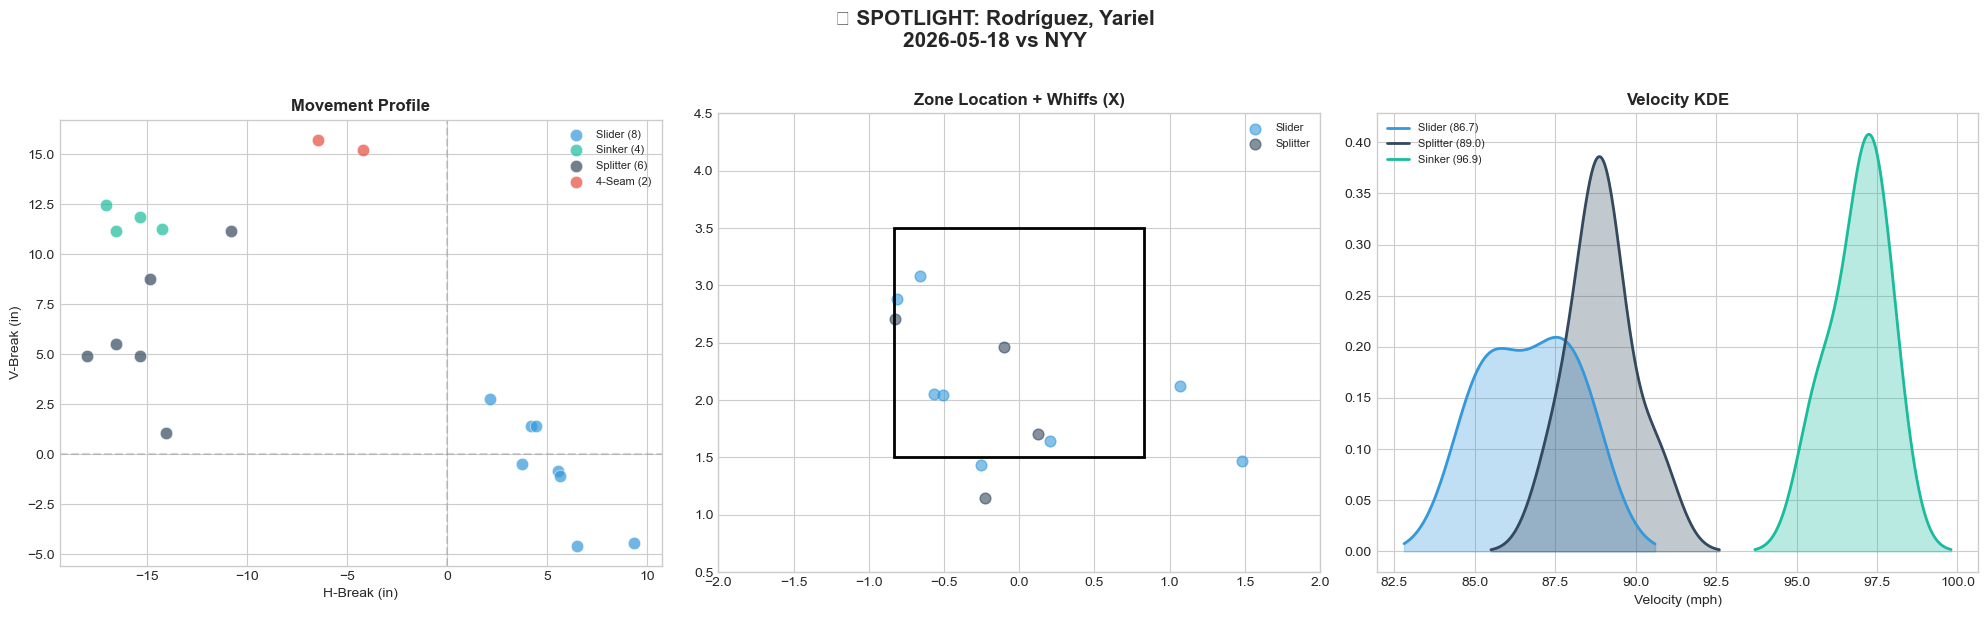


--- Game Summary ---
  K: 0 | BB: 1 | H: 3

--- Role Assessment ---
  📉 CONTACT MANAGER: Low whiff rate (0.0%), relies on weak contact


In [45]:
spotlight = jays_pitchers[jays_pitchers['player_name'] == SPOTLIGHT_PITCHER]

if len(spotlight) > 0:
    print("=" * 60)
    print("  🔦 PITCHER SPOTLIGHT: " + SPOTLIGHT_PITCHER)
    print("  " + str(len(spotlight)) + " pitches this game")
    print("=" * 60)

    print("\n--- Pitch Arsenal ---")
    print("{:<12} {:>4} {:>7} {:>7} {:>8} {:>7} {:>6}".format(
        'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%', 'Grade'))
    print("-" * 55)

    for pt in spotlight['pitch_type'].value_counts().index:
        pt_data = spotlight[spotlight['pitch_type'] == pt]
        count = len(pt_data)
        if count < 2:
            continue
        usage = count / len(spotlight) * 100
        avg_velo = pt_data['release_speed'].mean()

        swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                               'foul', 'foul_tip', 'hit_into_play',
                                               'hit_into_play_no_out', 'hit_into_play_score']).sum()
        whiff_rate = (swinging / swings * 100) if swings > 0 else 0
        called = (pt_data['description'] == 'called_strike').sum()
        csw = (swinging + called) / count * 100

        if whiff_rate >= 30: grade = '🟢 A'
        elif whiff_rate >= 20: grade = '🟢 B'
        elif whiff_rate >= 12: grade = '🟡 C'
        else: grade = '🔴 D'

        print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>7.1f}% {:>6.1f}%  {}".format(
            PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, grade))

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    ax1 = axes[0]
    for pt in spotlight['pitch_type'].unique():
        data = spotlight[spotlight['pitch_type'] == pt].dropna(subset=['pfx_x', 'pfx_z'])
        if len(data) >= 2:
            ax1.scatter(data['pfx_x'] * 12, data['pfx_z'] * 12,
                       c=PITCH_COLORS.get(pt, '#95a5a6'), s=80, alpha=0.7,
                       label=PITCH_NAMES.get(pt, pt) + " (" + str(len(data)) + ")",
                       edgecolors='white', linewidth=0.5)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax1.set_xlabel('H-Break (in)', fontsize=10)
    ax1.set_ylabel('V-Break (in)', fontsize=10)
    ax1.set_title('Movement Profile', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.set_aspect('equal')

    ax2 = axes[1]
    main_pt = spotlight['pitch_type'].value_counts().head(2).index.tolist()
    for pt in main_pt:
        data = spotlight[spotlight['pitch_type'] == pt].dropna(subset=['plate_x', 'plate_z'])
        if len(data) > 0:
            ax2.scatter(data['plate_x'], data['plate_z'],
                       c=PITCH_COLORS.get(pt, '#95a5a6'), s=60, alpha=0.6,
                       label=PITCH_NAMES.get(pt, pt))
            whiffs = data[data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])]
            if len(whiffs) > 0:
                ax2.scatter(whiffs['plate_x'], whiffs['plate_z'],
                           marker='x', s=120, c='red', linewidths=2.5, zorder=5)
    zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor='black', linewidth=2)
    ax2.add_patch(zone)
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(0.5, 4.5)
    ax2.set_title('Zone Location + Whiffs (X)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)

    ax3 = axes[2]
    for pt in spotlight['pitch_type'].value_counts().index:
        pt_data = spotlight[spotlight['pitch_type'] == pt]['release_speed'].dropna()
        if len(pt_data) >= 3:
            kde = gaussian_kde(pt_data)
            x_range = np.linspace(pt_data.min() - 2, pt_data.max() + 2, 200)
            ax3.fill_between(x_range, kde(x_range), alpha=0.3,
                            color=PITCH_COLORS.get(pt, '#95a5a6'))
            ax3.plot(x_range, kde(x_range),
                    color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2,
                    label=PITCH_NAMES.get(pt, pt) + " (" + str(round(pt_data.mean(), 1)) + ")")
    ax3.set_xlabel('Velocity (mph)', fontsize=10)
    ax3.set_title('Velocity KDE', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=8)

    plt.suptitle('🔦 SPOTLIGHT: ' + SPOTLIGHT_PITCHER + '\n' + GAME_DATE + ' vs ' + OPPONENT,
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../visualizations/spotlight_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    sp_k = len(spotlight[spotlight['events'] == 'strikeout'])
    sp_bb = len(spotlight[spotlight['events'].isin(['walk', 'hit_by_pitch'])])
    sp_hits = len(spotlight[spotlight['events'].isin(['single', 'double', 'triple', 'home_run'])])

    print("\n--- Game Summary ---")
    print("  K: " + str(sp_k) + " | BB: " + str(sp_bb) + " | H: " + str(sp_hits))
    print("\n--- Role Assessment ---")
    total_whiffs = spotlight['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
    whiff_pct = round(total_whiffs / len(spotlight) * 100, 1)
    if whiff_pct >= 15 and sp_k >= 2:
        print("  📈 HIGH-LEVERAGE CANDIDATE: Elite whiff rate (" + str(whiff_pct) + "%) + K ability")
    elif whiff_pct >= 10:
        print("  📊 MIDDLE RELIEF: Solid whiff rate (" + str(whiff_pct) + "%), reliable innings eater")
    else:
        print("  📉 CONTACT MANAGER: Low whiff rate (" + str(whiff_pct) + "%), relies on weak contact")
else:
    print("⚠️ " + SPOTLIGHT_PITCHER + " did not pitch in this game.")
    print("Change SPOTLIGHT_PITCHER in Cell 1 to analyze a different reliever.")

In [46]:
game_data.to_csv('../data/game_' + GAME_DATE + '.csv', index=False)
print("Game data saved: " + str(len(game_data)) + " pitches")

print("\n" + "=" * 60)
print("  REPORT v2.1 COMPLETE — " + GAME_DATE + " vs " + OPPONENT)
print("  Charts saved to ../visualizations/:")
charts = ['movement', 'zone', 'batted_balls', 'velocity', 'release', 'gamescore', 'wpa', 'spray', 'runvalue', 'spotlight']
for c in charts:
    print("    " + c + "_" + GAME_DATE + ".png")
if SEASON_RS > 0:
    print("    pythagorean_" + GAME_DATE + ".png")
print("=" * 60)

Game data saved: 4110 pitches

  REPORT v2.1 COMPLETE — 2026-05-18 vs NYY
  Charts saved to ../visualizations/:
    movement_2026-05-18.png
    zone_2026-05-18.png
    batted_balls_2026-05-18.png
    velocity_2026-05-18.png
    release_2026-05-18.png
    gamescore_2026-05-18.png
    wpa_2026-05-18.png
    spray_2026-05-18.png
    runvalue_2026-05-18.png
    spotlight_2026-05-18.png
